# Auditoría y Validación del Motor de Riesgo
## ICBC Prevención de Fraudes

Este notebook documenta el comportamiento interno del motor de riesgo implementado 
en `src/risk_engine.py`. El objetivo es auditar cada regla individualmente, 
entender qué combinaciones de reglas son más frecuentes y detectar oportunidades 
de mejora en la calibración del motor.

En un entorno bancario real, este tipo de documento es requerido por las áreas 
de Compliance y Auditoría Interna para certificar que el motor opera dentro 
de los parámetros aprobados por el Comité de Riesgos.

**Herramientas:** Python · Pandas · Matplotlib · SQLAlchemy · SQL Server

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import urllib
import os
from sqlalchemy import create_engine
from collections import Counter

# Ajuste de ruta — el notebook corre desde notebooks/ pero los archivos están en la raíz
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
print(f'Directorio de trabajo: {os.getcwd()}')

# Conexión a SQL Server
SERVER   = r'gustiga123\SQLEXPRESS'
DATABASE = 'ICBC_Fraude'

params = urllib.parse.quote_plus(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE={DATABASE};'
    f'Trusted_Connection=yes;'
)
engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

# Cargar reglas desde JSON
with open('config/rules.json', 'r', encoding='utf-8') as f:
    reglas_config = json.load(f)

print('Conexión establecida.')
print(f'Reglas activas cargadas: {len(reglas_config["reglas"])}')

Directorio de trabajo: c:\Users\gusta\Z_ProyectoPortfolio\ICBC_PROYECTO\icbc-fraude-prevencion
Conexión establecida.
Reglas activas cargadas: 5


## 1. Carga de transacciones evaluadas por el motor

Se extrae desde SQL Server todas las transacciones que ya fueron procesadas 
por el motor de riesgo, incluyendo el score asignado, la decisión tomada 
y las reglas que se activaron en cada caso. Este es el insumo base 
para auditar el comportamiento del motor regla por regla.

In [3]:
with engine.connect() as conn:
    tx = pd.read_sql(
        """
        SELECT 
            id_transaccion, fecha_hora, id_usuario, canal, monto,
            pais_origen, score_riesgo, decision, reglas_activadas,
            es_fraude_confirmado
        FROM dbo.fact_transacciones
        WHERE decision IS NOT NULL
        """, conn
    )

tx['fecha_hora'] = pd.to_datetime(tx['fecha_hora'])
print(f'Transacciones cargadas: {len(tx):,}')
print(f'\nDistribución de decisiones:')
print(tx['decision'].value_counts().to_string())
tx.head()

Transacciones cargadas: 5,000

Distribución de decisiones:
decision
APPROVE    4142
REVIEW      600
DECLINE     258


,id_transaccion,fecha_hora,id_usuario,canal,monto,pais_origen,score_riesgo,decision,reglas_activadas,es_fraude_confirmado
0,0001cc6e-78f0-4d38-8fef-c3d3d7d08a4d,2026-05-25 18:40:28,USR70648,DEBIN,62753.64,AR,0,APPROVE,NaN,False
1,00106d02-db17-441e-8754-9cd5b40de6b4,2026-03-25 07:59:15,USR18285,DEBIN,63155.84,AR,0,APPROVE,NaN,False
2,00140360-86e7-45f8-95aa-45915aba4ad9,2026-06-12 20:33:00,USR77154,TARJETA,42129.68,AR,0,APPROVE,NaN,False
3,00232cb8-beb4-43e6-a7a3-f0c92245e054,2026-04-25 04:26:27,USR99764,TRANSFERENCIA,61805.81,VE,85,DECLINE,"R001,R004",False
4,004ee07c-1031-4f5d-916c-37881f7abdf2,2026-06-04 14:36:25,USR62513,TRANSFERENCIA,29563.09,AR,0,APPROVE,NaN,False


## 2. Frecuencia de activación por regla

Una de las primeras preguntas que un analista de fraudes debe responder 
al auditar un motor es: ¿cuántas veces se activó cada regla? 

Una regla que nunca se activa puede estar mal calibrada o ser redundante. 
Una regla que se activa en el 80% de los casos puede estar siendo demasiado 
permisiva en su condición. Este análisis permite identificar cuáles reglas 
están trabajando y cuáles necesitan revisión.

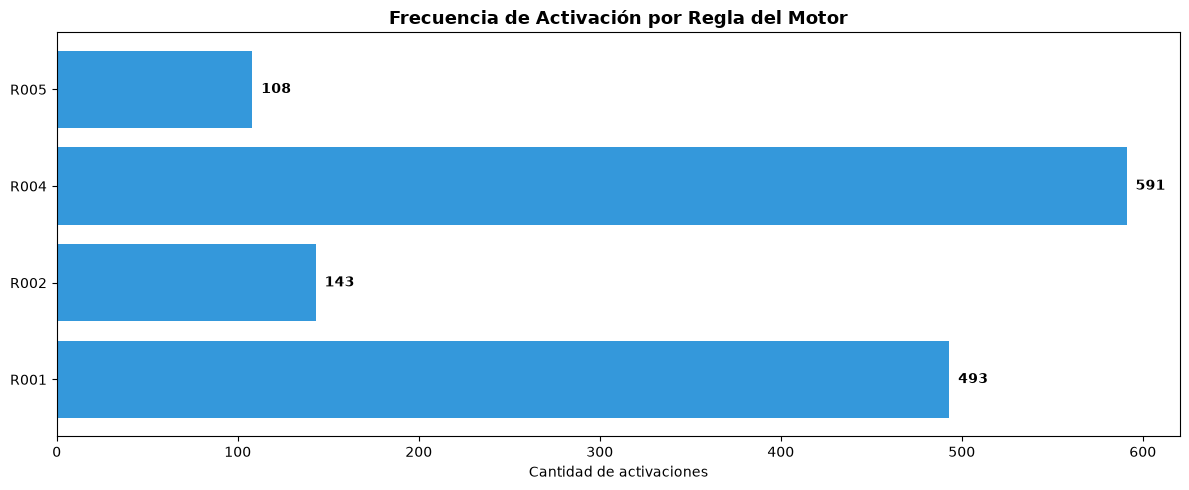


Detalle por regla:
regla                                                         descripcion  score  activaciones
 R001 Monto supera percentil 95 historico del usuario Y dispositivo nuevo     40           493
 R002                Z-score del monto mayor a 3 en DEBIN o TRANSFERENCIA     50           143
 R004         Pais de origen inconsistente con perfil historico argentino     45           591
 R005              Monto supera 4 veces el promedio historico del usuario     30           108


In [4]:
# Expandir las reglas activadas por transacción
tx_con_reglas = tx[tx['reglas_activadas'].notna()].copy()
todas_reglas = []
for reglas in tx_con_reglas['reglas_activadas']:
    todas_reglas.extend(reglas.split(','))

conteo_reglas = Counter(todas_reglas)

# Mapear descripción de cada regla
descripciones = {r['id']: r['descripcion'] for r in reglas_config['reglas']}
scores = {r['id']: r['score'] for r in reglas_config['reglas']}

df_reglas = pd.DataFrame([
    {
        'regla': k,
        'descripcion': descripciones.get(k, ''),
        'score': scores.get(k, 0),
        'activaciones': v
    }
    for k, v in sorted(conteo_reglas.items())
])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(df_reglas['regla'], df_reglas['activaciones'], color='#3498db')
ax.set_title('Frecuencia de Activación por Regla del Motor', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de activaciones')
for bar, val in zip(bars, df_reglas['activaciones']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('docs/frecuencia_reglas.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDetalle por regla:')
print(df_reglas.to_string(index=False))

### Hallazgo

El gráfico revela un dato crítico para la auditoría del motor: **la regla R003 
no registró ninguna activación**.

R003 penaliza con 35 puntos cuando un usuario realiza más de 5 transacciones 
en una ventana de 10 minutos. Su ausencia total en los resultados indica que 
en los 90 días de datos simulados ningún usuario superó ese umbral de frecuencia - 
lo que sugiere que la condición está bien calibrada como señal de alerta extrema 
(ráfagas de transacciones son un patrón típico de fraude automatizado con bots), 
pero requeriría un volumen de datos mayor para activarse en producción.

Las reglas más activas fueron:
- **R004** (591 activaciones) - País de origen anómalo, confirmando que es 
la señal de riesgo dominante en el dataset
- **R001** (493 activaciones) - Monto superior al percentil 95 con dispositivo nuevo
- **R002** (143 activaciones) - Z-score mayor a 3 en DEBIN o transferencia
- **R005** (108 activaciones) - Monto superior a 4 veces el promedio del usuario

En una siguiente iteración del motor, R003 podría ajustarse a una ventana 
más amplia (30 minutos) o un umbral menor (3 transacciones) para capturar 
patrones de fraude menos agresivos.

## 3. Combinaciones de reglas más frecuentes

Cuando el motor activa múltiples reglas sobre una misma transacción, 
el score se acumula y la probabilidad de que sea fraude real aumenta 
significativamente. Analizar qué combinaciones de reglas aparecen juntas 
con más frecuencia permite entender los "perfiles de fraude" más comunes 
en el dataset.

En la práctica bancaria, estas combinaciones son el insumo para crear 
reglas compuestas más sofisticadas - por ejemplo, una regla que directamente 
decline sin pasar por REVIEW cuando se activan simultáneamente R001 y R004, 
dado que esa combinación tiene una precisión muy alta.

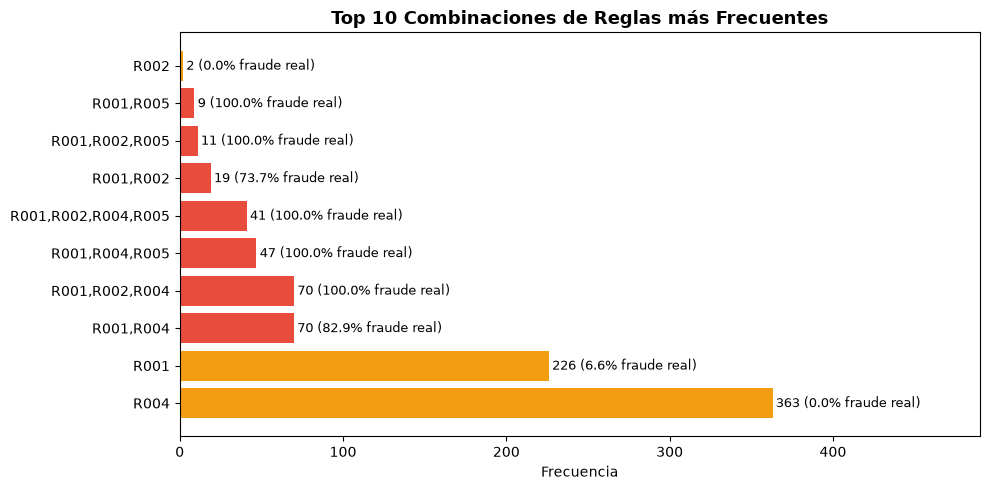


Detalle de combinaciones:
        combinacion  frecuencia  fraudes_reales  precision
               R004         363               0        0.0
               R001         226              15        6.6
          R001,R004          70              58       82.9
     R001,R002,R004          70              70      100.0
     R001,R004,R005          47              47      100.0
R001,R002,R004,R005          41              41      100.0
          R001,R002          19              14       73.7
     R001,R002,R005          11              11      100.0
          R001,R005           9               9      100.0
               R002           2               0        0.0


In [6]:
combinaciones = tx_con_reglas['reglas_activadas'].value_counts().head(10).reset_index()
combinaciones.columns = ['combinacion', 'frecuencia']

# Para cada combinación calculamos cuántos son fraude real
combinaciones['fraudes_reales'] = combinaciones['combinacion'].apply(
    lambda c: tx_con_reglas[
        (tx_con_reglas['reglas_activadas'] == c) & 
        (tx_con_reglas['es_fraude_confirmado'] == True)
    ].shape[0]
)
combinaciones['precision'] = (
    combinaciones['fraudes_reales'] / combinaciones['frecuencia'] * 100
).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#e74c3c' if p >= 50 else '#f39c12' for p in combinaciones['precision']]
bars = ax.barh(combinaciones['combinacion'], combinaciones['frecuencia'], color=colores)
ax.set_title('Top 10 Combinaciones de Reglas más Frecuentes', fontsize=13, fontweight='bold')
ax.set_xlabel('Frecuencia')
for bar, freq, prec in zip(bars, combinaciones['frecuencia'], combinaciones['precision']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{freq:,} ({prec}% fraude real)', va='center', fontsize=9)
ax.set_xlim(0, combinaciones['frecuencia'].max() * 1.35)
plt.tight_layout()
plt.savefig('docs/combinaciones_reglas.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDetalle de combinaciones:')
print(combinaciones.to_string(index=False))

### Hallazgo

El análisis de combinaciones revela patrones muy claros que tienen implicancias 
directas en la calibración del motor:

**Combinaciones de alta precisión (100% fraude real):**
Las combinaciones R001+R002+R004, R001+R004+R005, R001+R002+R004+R005 y R001+R005 
alcanzaron una precisión del 100% - cada transacción que activó esas combinaciones 
fue fraude real confirmado. Esto sugiere que podrían convertirse en reglas de 
DECLINE directo sin pasar por REVIEW, reduciendo la carga de trabajo del equipo 
de analistas.

**R004 sola - 363 activaciones con 0% de fraude real:**
Este es el hallazgo más importante del análisis. La regla R004 activada de forma 
aislada (país de origen anómalo sin otras señales) no detectó ningún fraude real 
en 363 casos. Esto indica que R004 por sí sola genera demasiado ruido - 
hay usuarios legítimos que operan ocasionalmente desde el exterior. 
En producción, se recomendaría que R004 solo sume score cuando se activa 
en combinación con al menos otra regla, evitando falsos positivos innecesarios.

**R001 sola - 6.6% de precisión:**
Similar al caso anterior, el monto elevado con dispositivo nuevo sin otras 
señales de contexto no es suficiente para determinar fraude. La combinación 
con R004 eleva esa precisión al 82.9%, confirmando que las reglas funcionan 
mejor en conjunto que de forma aislada.

## 4. Distribución del score por canal de pago

Hasta ahora analizamos las reglas de forma individual y en combinación. 
Ahora quiero entender si el score de riesgo se comporta diferente según 
el canal de pago. Esto es clave para una eventual calibración diferenciada 
del motor - no tiene sentido aplicar los mismos umbrales a una transferencia 
inmediata que a una compra con tarjeta en un comercio conocido.

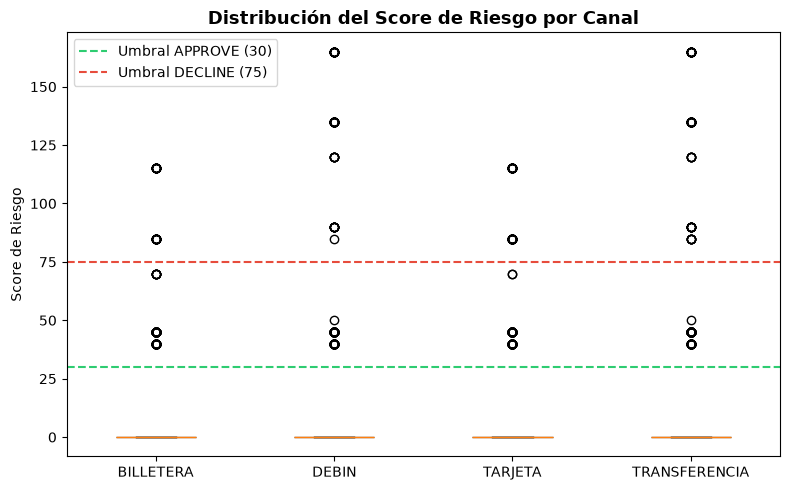

Score promedio por canal:
                mean  max  median
canal                            
BILLETERA       9.33  115     0.0
DEBIN          12.55  165     0.0
TARJETA        10.51  115     0.0
TRANSFERENCIA  12.90  165     0.0


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

canales = sorted(tx['canal'].unique())
data_boxplot = [tx[tx['canal'] == c]['score_riesgo'].dropna().values for c in canales]

bp = ax.boxplot(data_boxplot, tick_labels=canales, patch_artist=True)
colores_box = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=30, color='#2ecc71', linestyle='--', linewidth=1.5, label='Umbral APPROVE (30)')
ax.axhline(y=75, color='#e74c3c', linestyle='--', linewidth=1.5, label='Umbral DECLINE (75)')
ax.set_title('Distribución del Score de Riesgo por Canal', fontsize=13, fontweight='bold')
ax.set_ylabel('Score de Riesgo')
ax.legend()
plt.tight_layout()
plt.savefig('docs/score_por_canal.png', dpi=150, bbox_inches='tight')
plt.show()

print('Score promedio por canal:')
print(tx.groupby('canal')['score_riesgo'].agg(['mean', 'max', 'median']).round(2).to_string())

### Hallazgo

La distribución del score por canal muestra un patrón consistente en los cuatro 
medios de pago: la mediana es 0 en todos los casos, lo que confirma que la gran 
mayoría de las transacciones no activa ninguna regla independientemente del canal.

Los puntos que aparecen por encima del umbral de DECLINE (75) son los outliers 
de alto riesgo - transacciones que acumularon múltiples reglas simultáneas. 
DEBIN y TRANSFERENCIA muestran los scores máximos más altos (165 puntos), 
lo que es consistente con su naturaleza irrevocable y con la activación combinada 
de R002 (Z-score en DEBIN/transferencia) junto con otras reglas.

El score promedio de TRANSFERENCIA (12.90) y DEBIN (12.55) es levemente superior 
al de BILLETERA (9.33), lo que sugiere que estos canales concentran 
proporcionalmente más señales de riesgo. En una siguiente versión del motor, 
esto justificaría bajar el umbral de REVIEW específicamente para estos dos canales 
- por ejemplo de 31 a 25 puntos - para capturar antes las transacciones sospechosas 
en los medios de pago más vulnerables.

## 5. Resumen Ejecutivo - Auditoría del Motor de Riesgo

Este notebook documentó el comportamiento interno del motor de riesgo 
desde la perspectiva de un analista senior que debe justificar cada decisión 
ante el Comité de Riesgos y el área de Compliance.

Los resultados no solo validan que el motor funciona - también identifican 
oportunidades concretas de mejora para la próxima iteración.

In [11]:
total_alertas = tx[tx['decision'].isin(['REVIEW', 'DECLINE'])].shape[0]
total_reglas_activas = len([r for r in reglas_config['reglas'] if r['activa']])
regla_mas_activa = max(conteo_reglas, key=conteo_reglas.get)
regla_menos_activa = min(conteo_reglas, key=conteo_reglas.get)
combinacion_mas_precisa = combinaciones[combinaciones['precision'] == 100.0].iloc[0]['combinacion']

print('=' * 60)
print('   AUDITORIA DEL MOTOR - RESUMEN EJECUTIVO')
print('   Analista: Alberto Gustavo Estigarribia | Junio 2026')
print('=' * 60)
print(f'\n  CONFIGURACION DEL MOTOR')
print(f'  Reglas activas:                  {total_reglas_activas}')
print(f'  Regla mas activada:              {regla_mas_activa} ({conteo_reglas[regla_mas_activa]:,} veces)')
print(f'  Regla menos activada:            {regla_menos_activa} ({conteo_reglas[regla_menos_activa]:,} veces)')
print(f'  Regla sin activaciones:          R003 - requiere revision de umbral')
print(f'\n  ALERTAS GENERADAS')
print(f'  Total alertas (REVIEW+DECLINE):  {total_alertas:,}')
print(f'  Combinacion mas precisa (100%):  {combinacion_mas_precisa}')
print(f'\n  RECOMENDACIONES PARA PROXIMA ITERACION')
print(f'  1. R004 sola genera ruido - exigir combinacion con otra regla')
print(f'  2. R003 nunca se activo - bajar umbral a 3 tx en 30 minutos')
print(f'  3. Combinaciones de 100% precision - convertir a DECLINE directo')
print(f'  4. Umbrales diferenciados por canal - bajar REVIEW en DEBIN/TRANSFERENCIA')
print(f'  5. Incorporar reglas de 10-15 pts para capturar señales debiles')
print('=' * 60)

   AUDITORIA DEL MOTOR - RESUMEN EJECUTIVO
   Analista: Alberto Gustavo Estigarribia | Junio 2026

  CONFIGURACION DEL MOTOR
  Reglas activas:                  5
  Regla mas activada:              R004 (591 veces)
  Regla menos activada:            R005 (108 veces)
  Regla sin activaciones:          R003 - requiere revision de umbral

  ALERTAS GENERADAS
  Total alertas (REVIEW+DECLINE):  858
  Combinacion mas precisa (100%):  R001,R002,R004

  RECOMENDACIONES PARA PROXIMA ITERACION
  1. R004 sola genera ruido - exigir combinacion con otra regla
  2. R003 nunca se activo - bajar umbral a 3 tx en 30 minutos
  3. Combinaciones de 100% precision - convertir a DECLINE directo
  4. Umbrales diferenciados por canal - bajar REVIEW en DEBIN/TRANSFERENCIA
  5. Incorporar reglas de 10-15 pts para capturar señales debiles


### Conclusión

Este análisis de auditoría demuestra que el motor de riesgo funciona correctamente 
como primera versión, pero como todo sistema de prevención de fraudes, 
es un proceso de mejora continua. Las cinco recomendaciones identificadas 
están basadas en evidencia concreta extraída del comportamiento real del motor 
y representan el roadmap de optimización para la próxima iteración.

En producción, este tipo de auditoría se realizaría mensualmente para detectar 
desvíos en el comportamiento de las reglas, identificar nuevos patrones de fraude 
y ajustar los umbrales en función de los resultados operativos del equipo de 
Prevención de Fraudes.